In [ ]:
#%%capture
#%load_ext autoreload
#%autoreload 3

In [ ]:
#carrega o dataset
#!/bin/bash
!mkdir -p ~/Downloads
!curl -L -o ~/Downloads/beginner-chest-xray-image-classification.zip\
  https://www.kaggle.com/api/v1/datasets/download/vivek468/beginner-chest-xray-image-classification

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 2127M  100 2127M    0     0   157M      0  0:00:13  0:00:13 --:--:--  197M


In [ ]:
%%capture
%pip install -q numpy pandas matplotlib pillow --break-system-packages
%pip install tensorflow --break-system-packages
%pip install flatbuffers --upgrade --break-system-packages
%pip install torch torchvision --break-system-packages

In [ ]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())  # False no Raspberry Pi, é normal

2.10.0+cu128
True


In [ ]:
import os, matplotlib.pyplot as plt, numpy as np, urllib.request, zipfile, torch, torch.nn as nn
from PIL import Image
from torchvision import datasets, transforms, models
from torch.utils.data import random_split, DataLoader
from google.colab import drive, files

In [ ]:
#carrega o datasset
URL = "https://www.kaggle.com/api/v1/datasets/download/vivek468/beginner-chest-xray-image-classification"
DATASET_DIR = os.path.join(os.getcwd(), 'data', 'chest_xray')
ZIP_PATH = os.path.join(os.getcwd(), 'dataset.zip')

if not os.path.exists(DATASET_DIR):
    print("Baixando dataset...")
    urllib.request.urlretrieve(URL, ZIP_PATH)

    print("Descomprimindo...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(os.path.join(os.getcwd(), 'data'))

    os.remove(ZIP_PATH)  # apaga o zip após extrair
    print("Pronto!")
else:
    print("Dataset já existe, pulando download.")

Dataset já existe, pulando download.


In [ ]:
base_dir = os.path.join(os.getcwd(), "data", "chest_xray")

In [ ]:
base_dir

'/content/data/chest_xray'

In [ ]:
# Contar imagens em cada split
for split in ['train', 'test', 'pred']:
    for label in ['NORMAL', 'PNEUMONIA']:
        path = os.path.join(base_dir, split, label)
        count = len(os.listdir(path))
        print(f"{split}/{label}: {count} imagens")

train/NORMAL: 3432 imagens
train/PNEUMONIA: 3883 imagens
test/NORMAL: 234 imagens
test/PNEUMONIA: 386 imagens
pred/NORMAL: 4 imagens
pred/PNEUMONIA: 5 imagens


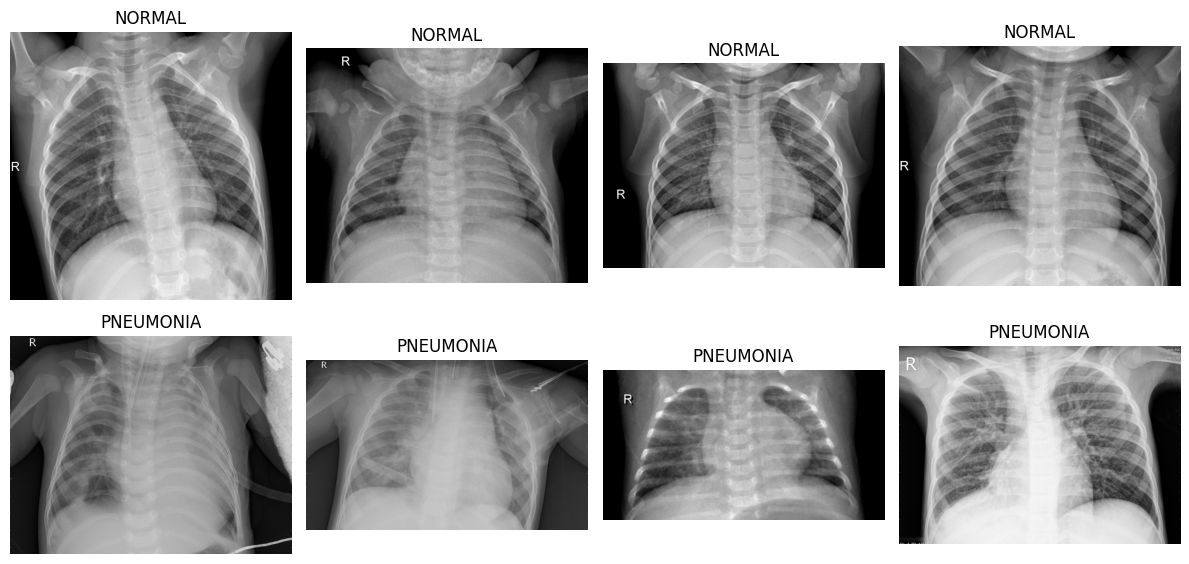

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for row, label in enumerate(['NORMAL', 'PNEUMONIA']):
    path = os.path.join(base_dir, 'train', label)
    images = os.listdir(path)[:4]

    for col, img_name in enumerate(images):
        img = Image.open(os.path.join(path, img_name))
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(label)
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
path = os.path.join(base_dir, 'train', 'NORMAL')
imagens = os.listdir(path)

tamanhos = []
modos = []

for img_name in imagens:
    img = Image.open(os.path.join(path, img_name))
    tamanhos.append(img.size)  # (largura, altura)
    modos.append(img.mode)     # RGB, L, etc.

tamanhos = np.array(tamanhos)

print(f"Largura  — min: {tamanhos[:,0].min()}, max: {tamanhos[:,0].max()}, média: {tamanhos[:,0].mean():.0f}")
print(f"Altura   — min: {tamanhos[:,1].min()}, max: {tamanhos[:,1].max()}, média: {tamanhos[:,1].mean():.0f}")
print(f"Modos encontrados: {set(modos)}")

Largura  — min: 912, max: 2916, média: 1677
Altura   — min: 496, max: 2713, média: 1379
Modos encontrados: {'L', 'RGB'}


In [ ]:
def carregar_imagem(caminho, tamanho=(224, 224)):
    img = Image.open(caminho)
    img = img.convert('RGB')        # padroniza para 3 canais
    img = img.resize(tamanho)       # redimensiona
    img = np.array(img)             # converte para array numpy
    img = img / 255.0               # normaliza pixels para [0, 1]
    return img

# Teste com uma imagem
img_teste = carregar_imagem(os.path.join(base_dir, 'train', 'NORMAL', os.listdir(os.path.join(base_dir, 'train', 'NORMAL'))[0]))

print(f"Shape: {img_teste.shape}")        # deve ser (224, 224, 3)
print(f"Min: {img_teste.min():.2f}")      # deve ser 0.0
print(f"Max: {img_teste.max():.2f}")      # deve ser 1.0

Shape: (224, 224, 3)
Min: 0.00
Max: 0.97


In [ ]:
# Transformações para treino (com augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),             # converte para tensor e normaliza [0,1]
])

# Transformações para teste (sem augmentation)
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Datasets
train_dataset = datasets.ImageFolder(os.path.join(base_dir, 'train'), transform=train_transforms)
test_dataset  = datasets.ImageFolder(os.path.join(base_dir, 'test'),  transform=test_transforms)

# DataLoaders (carregam em batches)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

# Verificar
print(f"Classes: {train_dataset.classes}")
print(f"Treino:  {len(train_dataset)} imagens")
print(f"Teste:   {len(test_dataset)} imagens")

Classes: ['NORMAL', 'PNEUMONIA']
Treino:  7315 imagens
Teste:   620 imagens


In [ ]:
print(train_dataset.class_to_idx)
# {'NORMAL': 0, 'PNEUMONIA': 1}

{'NORMAL': 0, 'PNEUMONIA': 1}


In [ ]:
imagens, rotulos = next(iter(train_loader))

print(f"Shape do batch de imagens: {imagens.shape}")
print(f"Shape dos rótulos:         {rotulos.shape}")
print(f"Valores min/max:           {imagens.min():.2f} / {imagens.max():.2f}")
print(f"Rótulos no batch:          {rotulos.unique()}")

Shape do batch de imagens: torch.Size([32, 3, 224, 224])
Shape dos rótulos:         torch.Size([32])
Valores min/max:           0.00 / 1.00
Rótulos no batch:          tensor([0, 1])


In [ ]:
# Carrega o modelo pré-treinado
model = models.efficientnet_b0(weights='IMAGENET1K_V1')

# Congela todos os parâmetros
for param in model.parameters():
    param.requires_grad = False

# Substitui a última camada
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 2)  # 2 classes

print(model.classifier)
print(f"\nParâmetros treináveis: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
print(f"Parâmetros congelados: {sum(p.numel() for p in model.parameters() if not p.requires_grad)}")

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)

Parâmetros treináveis: 2562
Parâmetros congelados: 4007548


In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

full_train_dataset = datasets.ImageFolder(
    os.path.join(base_dir, 'train'),
    transform=train_transforms
)

test_dataset = datasets.ImageFolder(
    os.path.join(base_dir, 'test'),
    transform=eval_transforms
)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# importante: trocar transform do val para eval
val_dataset.dataset.transform = eval_transforms

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Treino: {len(train_dataset)}")
print(f"Val:    {len(val_dataset)}")
print(f"Teste:  {len(test_dataset)}")

Treino: 5852
Val:    1463
Teste:  620


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device = "cpu"
model = model.to(device)
print(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier[1].parameters(), lr=1e-3)

cuda


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [ ]:
num_epochs = 3
best_val_acc = 0.0
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Época {epoch+1}/{num_epochs}")
    print(f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")
    print(f"Val   loss: {val_loss:.4f} | Val   acc: {val_acc:.4f}")
    print("-" * 50)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_pneumonia_model.pth")
        drive.mount('/content/drive')
        torch.save(model.state_dict(), "/content/drive/MyDrive/best_pneumonia_model.pth")
        files.download("/content/drive/MyDrive/best_pneumonia_model.pth")

Época 1/3
Train loss: 0.3138 | Train acc: 0.8792
Val   loss: 0.1905 | Val   acc: 0.9316
--------------------------------------------------
Mounted at /content/drive


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Época 2/3
Train loss: 0.2139 | Train acc: 0.9173
Val   loss: 0.1613 | Val   acc: 0.9371
--------------------------------------------------
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Época 3/3
Train loss: 0.1975 | Train acc: 0.9240
Val   loss: 0.1497 | Val   acc: 0.9433
--------------------------------------------------
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
files.download("best_pneumonia_model.pth")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Carregar o modelo para inferência

Primeiro, precisamos carregar o modelo que foi salvo anteriormente (`best_pneumonia_model.pth`). É importante carregar a arquitetura exata do modelo e depois carregar o `state_dict` (os pesos treinados) para ele.

In [ ]:
import torch
from torchvision import models, transforms
import torch.nn as nn
from PIL import Image
import os

# Carrega a mesma arquitetura do modelo
model_inference = models.efficientnet_b0(weights='IMAGENET1K_V1')

# Congela todos os parâmetros (mesmo que para treino)
for param in model_inference.parameters():
    param.requires_grad = False

# Substitui a última camada para 2 classes (NORMAL, PNEUMONIA)
num_features_inference = model_inference.classifier[1].in_features
model_inference.classifier[1] = nn.Linear(num_features_inference, 2)

# Carrega os pesos salvos
model_inference.load_state_dict(torch.load('best_pneumonia_model.pth', map_location=torch.device('cpu')))

# Define o modelo para modo de avaliação
model_inference.eval()

print("Modelo carregado com sucesso e pronto para inferência.")

Modelo carregado com sucesso e pronto para inferência.


### Função de Pré-processamento de Imagem

Para fazer uma previsão em uma nova imagem, ela precisa ser pré-processada exatamente da mesma forma que as imagens de validação/teste foram processadas (redimensionamento, conversão para tensor, normalização). O código abaixo define a transformação e uma função para carregar e pré-processar uma única imagem.

In [ ]:
# Transformações para uma única imagem (as mesmas de avaliação)
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

def predict_image(image_path, model, preprocess, class_names):
    # Carrega a imagem
    image = Image.open(image_path).convert('RGB')
    # Aplica as transformações
    image_tensor = preprocess(image)
    # Adiciona uma dimensão de batch (batch_size=1)
    image_tensor = image_tensor.unsqueeze(0)

    # Move para o dispositivo (CPU neste caso)
    device = "cpu"
    image_tensor = image_tensor.to(device)

    # Realiza a inferência
    with torch.no_grad():
        output = model(image_tensor)

    # Converte os logits para probabilidades (opcional, mas bom para entender)
    probabilities = torch.nn.functional.softmax(output, dim=1)

    # Pega a classe predita
    _, predicted_idx = torch.max(output, 1)
    predicted_class = class_names[predicted_idx.item()]

    return predicted_class, probabilities.squeeze().tolist()

print("Função predict_image definida.")

Função predict_image definida.


### Exemplo de Uso

Agora vamos testar a função de predição com uma imagem de exemplo. Vamos pegar uma imagem do seu conjunto de dados de teste.

Caminho da imagem: /content/data/chest_xray/pred/NORMAL/NORMAL_3.jpeg
Classe predita: NORMAL
Probabilidades: [0.9668230414390564, 0.033176954835653305]


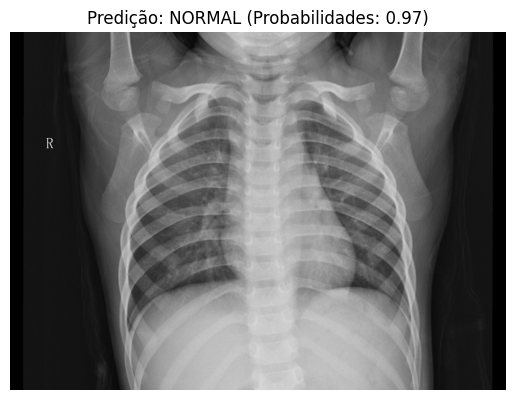

In [ ]:
# Definir os nomes das classes (como no seu dataset)
class_names = ['NORMAL', 'PNEUMONIA']

# Pega um caminho de imagem de exemplo (por exemplo, a primeira imagem de pneumonia no conjunto de teste)
example_image_path = os.path.join(base_dir, 'pred', 'NORMAL', os.listdir(os.path.join(base_dir, 'pred', 'NORMAL'))[3])

# Faz a predição
predicted_class, probabilities = predict_image(example_image_path, model_inference, preprocess, class_names)

print(f"Caminho da imagem: {example_image_path}")
print(f"Classe predita: {predicted_class}")
print(f"Probabilidades: {probabilities}")

# Exibe a imagem
import matplotlib.pyplot as plt
img = Image.open(example_image_path)
plt.imshow(img, cmap='gray')
plt.title(f"Predição: {predicted_class} (Probabilidades: {probabilities[class_names.index(predicted_class)]:.2f})")
plt.axis('off')
plt.show()